# cBioPortal data extraction tutorial

This notebook demonstrates how to:
1. Connect to the [cBioPortal](https://www.cbioportal.org/) repository for cancer genomics data sets.
2. List and explore cBioPortal studies.
3. View attribute and data type summaries for a selected study.
4. Extract molecular data (mutations, CNA, RNA-seq) and load each into netflow's `Keeper` for further analysis.

## Requirements
* Python 3.10
* The [Netflow](https://github.com/areElkin/netflow.git) package

---

## Import required libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from netflow.prep.extract import CBioPortalClient
from netflow.keepers.keeper import Keeper

## Connect to cBioPortal

In [3]:
cbio = CBioPortalClient()
print('Connected to cBioPortal.')

Connected to cBioPortal.


## View all available studies

Get a list of all CBioportal studies, filter them down to studies matching a known keyword, and view a descriptive summary of a selected study. 

In [4]:
all_studies = cbio.list_studies()
print(f'{len(all_studies)} studies available on cBioPortal.\n')

print('First 10 studies:')
for name in list(all_studies)[:10]:
    print(f' * {name}')

535 studies available on cBioPortal.

First 10 studies:
 * Breast Cancer (CPTAC GDC, 2025)
 * Glioma (MSK, Clin Cancer Res 2019)
 * Osteosarcoma (TARGET GDC, 2025)
 * Prostate Cancer MDA PCa PDX (MD Anderson, Clin Cancer Res 2024)
 * Uterine Endometrioid Carcinoma (CPTAC GDC, 2025)
 * Kidney Renal Papillary Cell Carcinoma (TCGA, PanCancer Atlas)
 * Urothelial Carcinoma (Cornell/Trento, Nat Gen 2016)
 * Basal Cell Carcinoma (UNIGE, Nat Genet 2016)
 * Endometrial Carcinoma (TCGA GDC, 2025)
 * Adenoid Cystic Carcinoma (JHU, Cancer Prev Res 2016)


## Search for studies matching keyword

In [5]:
keyword = 'MSK-IMPACT'
matches = [s for s in all_studies if keyword.lower() in s.lower()]
print(f'Studies matching "{keyword}":')
for m in matches:
    print(f'  {m}')

Studies matching "MSK-IMPACT":
  MSK-IMPACT 50K Clinical Sequencing Cohort (MSK, Cancer Cell 2026)
  MSK-IMPACT Clinical Sequencing Cohort (MSK, Nat Med 2017)
  MSK-IMPACT and MSK-ACCESS Mixed Cohort (MSK, Nat Commun 2021)
  Pan-Cancer MSK-IMPACT MET Validation Cohort (MSK 2022)
  MSK-IMPACT Heme Tumors (MSK, 2022)


____

## Inspect selected study

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
STUDY_NAME = 'MSK-IMPACT Clinical Sequencing Cohort (MSK, Nat Med 2017)'

# Get study ID and description
study_id = cbio.get_study_id(STUDY_NAME)
print(f'Study ID: {study_id}')

Study ID: msk_impact_2017


### *Study description*

In [8]:
desc = cbio.get_study_description(STUDY_NAME)
print('Study summary:')
display(desc[['name', 'description', 'cancerTypeId', 'referenceGenome', 'sequencedSampleCount']])

Study summary:


,name,description,cancerTypeId,referenceGenome,sequencedSampleCount
0,"MSK-IMPACT Clinical Sequencing Cohort (MSK, Na...","Targeted sequencing of 10,000 clinical cases u...",mixed,hg19,10945


### *List all molecular data profiles available in this study*

In [9]:
# All molecular data types available in this study
data_types_df = cbio.get_study_attribute(STUDY_NAME, 'data_types')
print('Molecular data profiles available:')
display(data_types_df)

Molecular data profiles available:


,name,id
0,Copy Number Alterations (MSK-IMPACT),msk_impact_2017_cna
1,Mutations (MSK-IMPACT),msk_impact_2017_mutations
2,Structural variants,msk_impact_2017_structural_variants


### *Cancer-type breakdown*

In [10]:
cancer_types = cbio.get_study_attribute(STUDY_NAME, 'cancer_types')
print('Top 10 cancer types by sample count:')
display(cancer_types.head(10))

Top 10 cancer types by sample count:


,type,sampleCount
0,Non-Small Cell Lung Cancer,1668
1,Breast Cancer,1337
2,Colorectal Cancer,1007
3,Prostate Cancer,717
4,Glioma,553
5,Pancreatic Cancer,502
6,Soft Tissue Sarcoma,443
7,Bladder Cancer,423
8,Melanoma,365
9,Renal Cell Carcinoma,361


###  *View patient clinical attributes*

In [11]:
clinical_attrs = cbio.list_study_attributes(STUDY_NAME)
print(f'{len(clinical_attrs)} clinical attributes available:\n')
print(*clinical_attrs, sep='\n')

24 clinical attributes available:

CANCER_TYPE
CANCER_TYPE_DETAILED
DNA_INPUT
FRACTION_GENOME_ALTERED
MATCHED_STATUS
METASTATIC_SITE
MUTATION_COUNT
ONCOTREE_CODE
OS_MONTHS
OS_STATUS
PRIMARY_SITE
SAMPLE_CLASS
SAMPLE_COLLECTION_SOURCE
SAMPLE_COUNT
SAMPLE_COVERAGE
SAMPLE_TYPE
SEX
SMOKING_HISTORY
SOMATIC_STATUS
SPECIMEN_PRESERVATION_TYPE
SPECIMEN_TYPE
TMB_NONSYNONYMOUS
TUMOR_PURITY
VITAL_STATUS


----

## Extract data

#### ***Data types***
    * Patient clinical attributes
    * Mutation 
    * CNA 
    * RNA-seq expression
    * DNA Methylation
    * Structural variants

Each section below calls the CBioPortalClient method to extract one of the types above and prints a summary of the data.  
*Note*: Data pulls may take a few minutes for large cohorts.

---

### *Patient clinical attributes*

* `get_clinical_data`() combines sample metadata (primary site, sample type, tumor purity) with patient metadata (OS months, OS status)

In [12]:
clin_df = cbio.get_clinical_data(STUDY_NAME)
print(f'Clinical data shape: {clin_df.shape}  (samples × attributes)')
# Display clinical data for first 5 samples
display(clin_df.head(5))

Clinical data shape: (10945, 7)  (samples × attributes)


,patientId,primaryTumorSite,sampleType,tumorPurity,osMonths,osStatus,osGroup
sampleId,,,,,,,
P-0000004-T01-IM3,P-0000004,Breast,Primary,50,<NA>,0:LIVING,0.0
P-0000015-T01-IM3,P-0000015,Breast,Metastasis,40,<NA>,1:DECEASED,1.0
P-0000023-T01-IM3,P-0000023,Peritoneum,Primary,30,<NA>,1:DECEASED,1.0
P-0000024-T01-IM3,P-0000024,Uterus,Metastasis,40,<NA>,0:LIVING,0.0
P-0000025-T01-IM3,P-0000025,Uterus,Primary,NaN,<NA>,0:LIVING,0.0


In [13]:
sample_ids = clin_df.index.to_list()

### *Extract mutation data and load into Netflow's Keeper*

* `get_mutation_data()` returns a binary matrix *(n_genes, n_samples)* where 1 indicates gene mutations in a sample , 0 otherwise.   

*Note*: 
* Data extraction utilities like `get_mutation_data()` return both the raw data (`mut_raw`) and the processed version (`mut_proc`) that can be readily imported to the Keeper. `mut_proc` is a *(n_features, n_observations)* (or) *(n_genes, n_samples)* dataframe.

In [14]:
print('Fetching mutation data...')
mut_raw, mut_proc = cbio.get_mutation_data(STUDY_NAME)

print(f'\nMutation matrix shape: {mut_proc.shape}  (genes × samples)')
print(f'Fraction of gene/sample pairs mutated: {mut_proc.values.mean():.4f}')
display(mut_proc.iloc[:5, :5])

Fetching mutation data...

Mutation matrix shape: (413, 10129)  (genes × samples)
Fraction of gene/sample pairs mutated: 0.0165


,P-0000004-T01-IM3,P-0000015-T01-IM3,P-0000023-T01-IM3,P-0000024-T01-IM3,P-0000025-T01-IM3
hugoGeneSymbol,,,,,
ABL1,0,0,0,0,0
ABRAXAS1,0,0,0,0,0
ACVR1,0,0,0,0,0
AKT1,1,0,0,0,0
AKT2,0,0,0,0,0


In [15]:
# View most frequently mutated genes
mutation_freq = mut_proc.sum(axis=1).sort_values(ascending=False)
print('Top 10 most frequently mutated genes:')
display(mutation_freq.head(10).rename('n_samples_mutated').to_frame())

Top 10 most frequently mutated genes:


,n_samples_mutated
hugoGeneSymbol,
TP53,4538
KRAS,1643
TERT,1460
PIK3CA,1355
APC,1121
ARID1A,875
KMT2D,851
PTEN,665
KMT2C,642


### *Extract CNA data and load it into the Keeper*

`get_cna_data()` returns an integer *(genes, samples)*  matrix where -2 represents deep deletion, -1 - shallow deletion, 0 - diploid, 1 - shallow gain, 2-amplification.

In [16]:
print('Fetching CNA data...')
cna_raw, cna_proc = cbio.get_cna_data(STUDY_NAME)

print(f'\nCNA matrix shape: {cna_raw.shape}  (genes × samples)')
display(cna_proc.head(5))

Fetching CNA data...

CNA matrix shape: (4487450, 9)  (genes × samples)


	P-0000004-T01-IM3	P-0000015-T01-IM3	P-0000023-T01-IM3	P-0000024-T01-IM3	P-0000025-T01-IM3	P-0000025-T02-IM5	P-0000026-T01-IM3	P-0000027-T01-IM3	P-0000030-T01-IM3	P-0000034-T01-IM3	P-0000036-T01-IM3	P-0000037-T01-IM3	P-0000037-T02-IM3	P-0000039-T01-IM3	P-0000041-T01-IM3	P-0000042-T01-IM3	P-0000043-T02-IM3	P-0000047-T01-IM3	P-0000053-T01-IM3	P-0000055-T01-IM3	P-0000056-T01-IM3	P-0000057-T01-IM3	P-0000058-T01-IM3	P-0000059-T01-IM3	P-0000060-T01-IM3	P-0000061-T01-IM3	P-0000062-T01-IM3	P-0000063-T01-IM3	P-0000064-T02-IM3	P-0000065-T01-IM3	P-0000066-T01-IM3	P-0000066-T02-IM5	P-0000067-T01-IM3	P-0000067-T02-IM5	P-0000068-T01-IM3	P-0000069-T01-IM3	P-0000071-T01-IM3	P-0000073-T01-IM3	P-0000075-T01-IM3	P-0000076-T01-IM3	P-0000077-T01-IM3	P-0000079-T01-IM3	P-0000080-T01-IM3	P-0000081-T01-IM3	P-0000082-T01-IM3	P-0000083-T01-IM3	P-0000084-T01-IM3	P-0000085-T02-IM3	P-0000086-T01-IM3	P-0000088-T01-IM3	P-0000092-T01-IM3	P-0000093-T01-IM3	P-0000095-T01-IM3	P-0000096-T01-IM3	P-0000098-T01-IM3	P-0000100

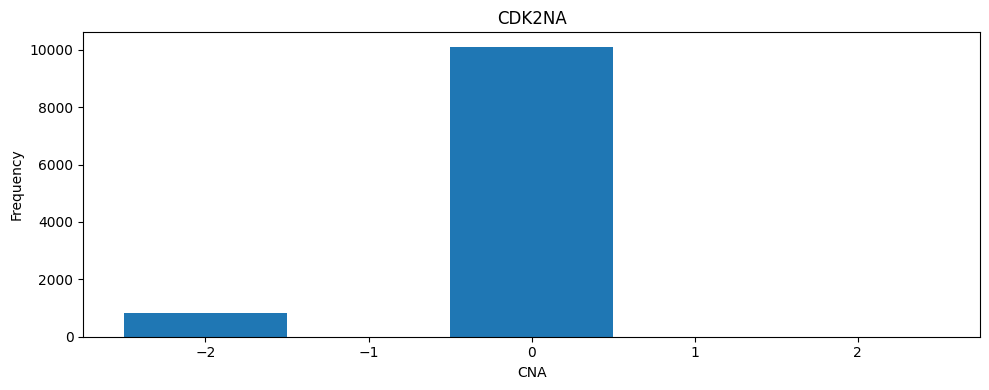

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

alterFreq = np.argmax((cna_proc!=0).sum(axis=1))
topAltered = cna_proc.index[alterFreq]
geneAlt = cna_proc.loc[topAltered]
bins = np.arange(geneAlt.min(), geneAlt.max() + 2) - 0.5
geneAlt.hist(ax=ax, bins=bins, grid=False)

ax.set_ylabel('Frequency')
ax.set_xlabel('CNA')
ax.set_title('CDK2NA')
plt.tight_layout()
plt.show()

## *Extract RNA seq data*

In [19]:
STUDY_NAME_2 = 'Breast Invasive Carcinoma (TCGA, PanCancer Atlas)'
rna_types, rna_ids = cbio.list_study_data(STUDY_NAME_2)
rna_raw, rna_proc = cbio.get_rna_seq_data(STUDY_NAME_2)

In [20]:
print(f'RNA-seq df shape: {rna_proc.shape}')
rna_proc.head(3)

RNA-seq df shape: (20338, 1082)


	TCGA-3C-AAAU-01	TCGA-3C-AALI-01	TCGA-3C-AALJ-01	TCGA-3C-AALK-01	TCGA-4H-AAAK-01	TCGA-5L-AAT0-01	TCGA-5T-A9QA-01	TCGA-A1-A0SB-01	TCGA-A1-A0SD-01	TCGA-A1-A0SE-01	TCGA-A1-A0SF-01	TCGA-A1-A0SG-01	TCGA-A1-A0SH-01	TCGA-A1-A0SI-01	TCGA-A1-A0SJ-01	TCGA-A1-A0SK-01	TCGA-A1-A0SM-01	TCGA-A1-A0SN-01	TCGA-A1-A0SO-01	TCGA-A1-A0SP-01	TCGA-A1-A0SQ-01	TCGA-A2-A04N-01	TCGA-A2-A04P-01	TCGA-A2-A04Q-01	TCGA-A2-A04R-01	TCGA-A2-A04T-01	TCGA-A2-A04U-01	TCGA-A2-A04V-01	TCGA-A2-A04W-01	TCGA-A2-A04X-01	TCGA-A2-A04Y-01	TCGA-A2-A0CK-01	TCGA-A2-A0CL-01	TCGA-A2-A0CM-01	TCGA-A2-A0CO-01	TCGA-A2-A0CP-01	TCGA-A2-A0CQ-01	TCGA-A2-A0CR-01	TCGA-A2-A0CS-01	TCGA-A2-A0CT-01	TCGA-A2-A0CU-01	TCGA-A2-A0CV-01	TCGA-A2-A0CW-01	TCGA-A2-A0CX-01	TCGA-A2-A0CZ-01	TCGA-A2-A0D0-01	TCGA-A2-A0D1-01	TCGA-A2-A0D2-01	TCGA-A2-A0D3-01	TCGA-A2-A0D4-01	TCGA-A2-A0EM-01	TCGA-A2-A0EN-01	TCGA-A2-A0EO-01	TCGA-A2-A0EP-01	TCGA-A2-A0EQ-01	TCGA-A2-A0ER-01	TCGA-A2-A0ES-01	TCGA-A2-A0ET-01	TCGA-A2-A0EU-01	TCGA-A2-A0EV-01	TCGA-A2-A0EW-01	TCGA-A2-A0EX-01	TCGA-A2

## *Extract DNA methylation data*

In [21]:
STUDY_NAME_3 = 'Breast Invasive Carcinoma (TCGA, Cell 2015)'
__, methyl_proc = cbio.get_methylation_data(STUDY_NAME_3)

print(f'Methylation df shape: {methyl_proc.shape}')
methyl_proc.head(3)

Methylation df shape: (1643, 264)


	TCGA-A1-A0SD-01	TCGA-A2-A04N-01	TCGA-A2-A04P-01	TCGA-A2-A04Q-01	TCGA-A2-A04T-01	TCGA-A2-A04U-01	TCGA-A2-A04V-01	TCGA-A2-A04W-01	TCGA-A2-A04X-01	TCGA-A2-A04Y-01	TCGA-A2-A0CL-01	TCGA-A2-A0CM-01	TCGA-A2-A0CP-01	TCGA-A2-A0CQ-01	TCGA-A2-A0CS-01	TCGA-A2-A0CU-01	TCGA-A2-A0CV-01	TCGA-A2-A0CW-01	TCGA-A2-A0D0-01	TCGA-A2-A0D2-01	TCGA-A2-A0D3-01	TCGA-A2-A0D4-01	TCGA-A2-A0EM-01	TCGA-A2-A0EO-01	TCGA-A2-A0EQ-01	TCGA-A2-A0ER-01	TCGA-A2-A0ES-01	TCGA-A2-A0ET-01	TCGA-A2-A0EV-01	TCGA-A2-A0EW-01	TCGA-A2-A0EX-01	TCGA-A2-A0EY-01	TCGA-A2-A0T3-01	TCGA-A7-A0CD-01	TCGA-A7-A0CE-01	TCGA-A7-A0CG-01	TCGA-A7-A0CH-01	TCGA-A7-A0CJ-01	TCGA-A7-A0DA-01	TCGA-A7-A0DB-01	TCGA-A8-A06N-01	TCGA-A8-A06O-01	TCGA-A8-A06P-01	TCGA-A8-A06Q-01	TCGA-A8-A06R-01	TCGA-A8-A06T-01	TCGA-A8-A06U-01	TCGA-A8-A06Y-01	TCGA-A8-A06Z-01	TCGA-A8-A076-01	TCGA-A8-A079-01	TCGA-A8-A07B-01	TCGA-A8-A07E-01	TCGA-A8-A07F-01	TCGA-A8-A07G-01	TCGA-A8-A07I-01	TCGA-A8-A07J-01	TCGA-A8-A07L-01	TCGA-A8-A07O-01	TCGA-A8-A07P-01	TCGA-A8-A07R-01	TCGA-A8-A07U-01	TCGA-A8

## *Extract structural variant data*

In [23]:
target_col = 'tumorPairedEndReadCount'
__ , sv_proc = cbio.get_structural_variant_data(STUDY_NAME_2, target_col)
print(f'Structural variant df shape: {sv_proc.shape}')

Structural variant df shape: (3283, 852)


In [24]:
# Display genes with the most structural variant events
var_gene = (sv_proc != 'missing').sum(axis=1).sort_values(ascending=False)
top_genes = var_gene.head(5)
print("Top 5 genes by samples with structural variants:")
print(top_genes.to_string())

# Display target_col for the top genes 
top_gene_names = top_genes.index
subset = sv_proc.loc[top_gene_names].replace('missing', pd.NA).dropna(axis=1, how='all')
print(f"{subset.shape[1]} samples with at least one event")
print(f"{target_col} for top 5 genes:")
print(subset.iloc[:, :8].to_string())

Top 5 genes by samples with structural variants:
site1HugoSymbol
BCAS3      21
FBXL20     21
SHANK2     18
RARA       18
Unknown    17

84 samples with at least one event
tumorPairedEndReadCount for top 5 genes:
sampleId        TCGA-3C-AALI-01 TCGA-A1-A0SJ-01 TCGA-A1-A0SM-01 TCGA-A2-A04V-01 TCGA-A2-A04W-01 TCGA-A2-A0CZ-01 TCGA-A2-A0D1-01 TCGA-A2-A0D4-01
site1HugoSymbol                                                                                                                                
BCAS3                      <NA>            16.0            <NA>            <NA>            <NA>             8.0            <NA>            <NA>
FBXL20                   1000.0            <NA>            31.0            <NA>            <NA>            <NA>            <NA>            <NA>
SHANK2                     <NA>            <NA>            <NA>            11.0            <NA>            <NA>            <NA>            <NA>
RARA                       <NA>            <NA>            42.0     

## Loading CBioPortal data into the Keeper

### Add data from a study into the Keeper

In [25]:
# Initialise Keeper with sample IDs 
keeper = Keeper(observation_labels=sample_ids)

# Load mutation data 
mut_aligned = mut_proc.reindex(columns=sample_ids)
keeper.add_data(mut_aligned, 'mutation')
# Load CNA data
cna_aligned = cna_proc.reindex(columns=sample_ids)
keeper.add_data(cna_aligned, 'cna')

### Data summary

In [26]:
print(f'Keeper observation count: {len(keeper.observation_labels)}')
print(f'Data modalities loaded:   {list(keeper.data.keys())}\n')
for key in keeper.data.keys():
    frame = keeper.data[key].to_frame()
    print(f'  [{key}]  shape: {frame.shape}  dtype: {frame.dtypes.unique()[0]}')

Keeper observation count: 10945
Data modalities loaded:   ['mutation', 'cna']

  [mutation]  shape: (413, 10945)  dtype: float64
  [cna]  shape: (410, 10945)  dtype: int64
